In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file = "Data.xlsx"

markets = pd.read_excel(file, sheet_name="Markets")
daily = pd.read_excel(file, sheet_name="Daily metrics")
audience = pd.read_excel(file, sheet_name="Audience overlap")
operations = pd.read_excel(file, sheet_name="Operations calendar")

print("Markets:")
display(markets.head())

print("Daily Metrics:")
display(daily.head())

print("Audience Overlap:")
display(audience.head())

print("Operations Calendar:")
display(operations.head())

Markets:


,state,state_name,can_increase_spend,delivery_group,planned_bau_daily_spend_usd,audited_last_28d_revenue_usd
0,OH,Ohio,1,OH,8003.53,2432183.37
1,PA,Pennsylvania,1,PA,9461.11,2837053.11
2,MI,Michigan,1,MI,6506.54,1943186.37
3,WI,Wisconsin,1,WI,6014.92,1786025.45
4,MO,Missouri,1,MO,7009.15,2121349.69


Daily Metrics:


,date,state,net_revenue_usd,orders,paid_social_spend_usd,platform_attributed_revenue_usd,revenue_feed_complete
0,2026-01-12,CA,355365.87,3400,33979.10,139963.34,1
1,2026-01-12,CO,91888.19,917,9060.01,39133.94,1
2,2026-01-12,FL,117150.64,1188,11499.19,48283.97,1
3,2026-01-12,GA,80477.19,813,7928.14,34700.79,1
4,2026-01-12,IN,75608.89,743,7475.16,31794.19,1


Audience Overlap:


,state_a,state_b,cross_border_audience_share,basis
0,NC,SC,0.23,Share of observed paid-social users seen in bo...
1,OH,PA,0.03,Share of observed paid-social users seen in bo...
2,MI,IN,0.02,Share of observed paid-social users seen in bo...
3,TN,KY,0.04,Share of observed paid-social users seen in bo...


Operations Calendar:


,state_scope,start_date,end_date,event,operations_note
0,ALL,2026-03-23,2026-03-29,National spring sale,Same offer and dates in all 16 states. No repe...
1,GA,2026-04-13,2026-04-16,Warehouse revenue feed incident,Daily sales export returned zero when incomple...
2,TX,2026-04-27,NaT,Fulfilment expansion,New distribution capacity went live. No rollba...
3,CO,2026-05-04,NaT,Platform reporting change,Paid-social attribution window changed from 7-...
4,FL,2026-06-08,2026-06-21,Local online promotion,"State-only 20% online discount and email push,..."


SECTION 1 — RAW DATA ANALYSIS

In [2]:
print("Markets shape:", markets.shape)
print("Daily metrics shape:", daily.shape)
print("Audience overlap shape:", audience.shape)
print("Operations calendar shape:", operations.shape)

Markets shape: (16, 6)
Daily metrics shape: (2260, 7)
Audience overlap shape: (4, 4)
Operations calendar shape: (7, 5)


In [3]:
print(markets.columns)
print(daily.columns)
print(audience.columns)
print(operations.columns)

Index(['state', 'state_name', 'can_increase_spend', 'delivery_group',
       'planned_bau_daily_spend_usd', 'audited_last_28d_revenue_usd'],
      dtype='object')
Index(['date', 'state', 'net_revenue_usd', 'orders', 'paid_social_spend_usd',
       'platform_attributed_revenue_usd', 'revenue_feed_complete'],
      dtype='object')
Index(['state_a', 'state_b', 'cross_border_audience_share', 'basis'], dtype='object')
Index(['state_scope', 'start_date', 'end_date', 'event', 'operations_note'], dtype='object')


In [4]:
print("Missing values in Markets:")
print(markets.isnull().sum())

print("\nMissing values in Daily Metrics:")
print(daily.isnull().sum())

print("\nMissing values in Audience Overlap:")
print(audience.isnull().sum())

print("\nMissing values in Operations Calendar:")
print(operations.isnull().sum())

Missing values in Markets:
state                           0
state_name                      0
can_increase_spend              0
delivery_group                  0
planned_bau_daily_spend_usd     0
audited_last_28d_revenue_usd    0
dtype: int64

Missing values in Daily Metrics:
date                               0
state                              0
net_revenue_usd                    8
orders                             0
paid_social_spend_usd              0
platform_attributed_revenue_usd    0
revenue_feed_complete              0
dtype: int64

Missing values in Audience Overlap:
state_a                        0
state_b                        0
cross_border_audience_share    0
basis                          0
dtype: int64

Missing values in Operations Calendar:
state_scope        0
start_date         0
end_date           2
event              0
operations_note    0
dtype: int64


In [5]:
missing_revenue = daily[daily["net_revenue_usd"].isnull()]

print(missing_revenue)

          date state  net_revenue_usd  orders  paid_social_spend_usd  \
339 2026-02-02   GA               NaN     826                7960.78   
387 2026-02-05    GA              NaN     818                8013.00   
451 2026-02-09    GA              NaN     781                8024.55   
499 2026-02-12    GA              NaN     814                7981.99   
563 2026-02-16    GA              NaN     867                8081.57   
611 2026-02-19    GA              NaN     895                8124.23   
675 2026-02-23    GA              NaN     845                8036.05   
723 2026-02-26    GA              NaN     842                7913.12   

     platform_attributed_revenue_usd  revenue_feed_complete  
339                         35017.93                      1  
387                         33651.64                      1  
451                         32423.11                      1  
499                         34677.80                      1  
563                         36236.37     

In [6]:
print("Number of duplicate rows:",
      daily.duplicated().sum())

Number of duplicate rows: 20


In [7]:
daily = daily.drop_duplicates()

print("Shape after removing duplicates:",
      daily.shape)

Shape after removing duplicates: (2240, 7)


In [9]:
daily["state"] = daily["state"].astype(str).str.strip().str.upper()
markets["state"] = markets["state"].astype(str).str.strip().str.upper()

In [10]:
print(sorted(daily["state"].unique()))

['CA', 'CO', 'FL', 'GA', 'IN', 'KY', 'MI', 'MO', 'NC', 'NV', 'OH', 'PA', 'SC', 'TN', 'TX', 'WI']


In [11]:
daily["date"] = pd.to_datetime(daily["date"])

print("Start date:", daily["date"].min())
print("End date:", daily["date"].max())

Start date: 2026-01-12 00:00:00
End date: 2026-05-31 00:00:00


In [12]:
state_revenue = (
    markets.groupby("state_name")["audited_last_28d_revenue_usd"]
    .sum()
    .sort_values(ascending=False)
)

print(state_revenue)

state_name
California        10032181.32
Texas              5391706.39
Florida            3540331.63
Pennsylvania       2837053.11
Colorado           2744745.41
Tennessee          2544780.10
Ohio               2432183.37
Georgia            2395848.87
Indiana            2281337.99
Missouri           2121349.69
North Carolina     2079247.48
Michigan           1943186.37
Wisconsin          1786025.45
South Carolina     1783246.37
Kentucky           1679472.47
Nevada              585013.64
Name: audited_last_28d_revenue_usd, dtype: float64


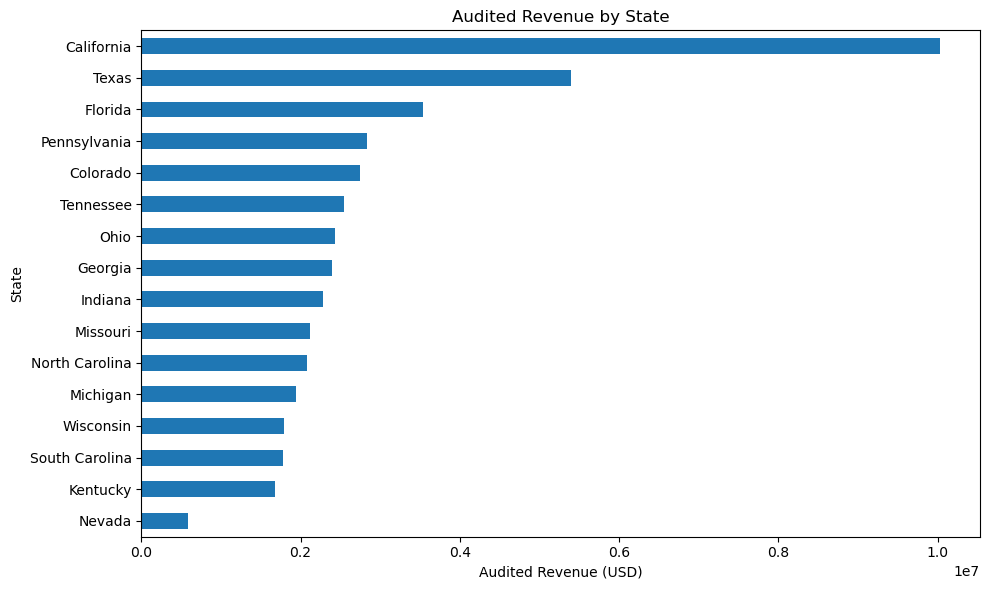

In [13]:
plt.figure(figsize=(10,6))

state_revenue.sort_values().plot(kind="barh")

plt.xlabel("Audited Revenue (USD)")
plt.ylabel("State")
plt.title("Audited Revenue by State")
plt.tight_layout()

plt.show()

In [14]:
total_revenue = markets["audited_last_28d_revenue_usd"].sum()

print("Total audited revenue:",
      total_revenue)

Total audited revenue: 46177709.660000004


In [15]:
markets["revenue_share"] = (
    markets["audited_last_28d_revenue_usd"]
    / total_revenue
)

display(
    markets[
        ["state", "state_name",
         "audited_last_28d_revenue_usd",
         "revenue_share"]
    ].sort_values("revenue_share", ascending=False)
)

,state,state_name,audited_last_28d_revenue_usd,revenue_share
8,CA,California,10032181.32,0.217252
9,TX,Texas,5391706.39,0.116760
10,FL,Florida,3540331.63,0.076668
1,PA,Pennsylvania,2837053.11,0.061438
15,CO,Colorado,2744745.41,0.059439
6,TN,Tennessee,2544780.10,0.055108
0,OH,Ohio,2432183.37,0.052670
11,GA,Georgia,2395848.87,0.051883
5,IN,Indiana,2281337.99,0.049403
4,MO,Missouri,2121349.69,0.045939


In [16]:
markets["revenue_share_percent"] = (
    markets["revenue_share"] * 100
)

display(
    markets[
        ["state_name", "revenue_share_percent"]
    ].sort_values("revenue_share_percent",
                  ascending=False)
)

,state_name,revenue_share_percent
8,California,21.725160
9,Texas,11.675994
10,Florida,7.666754
1,Pennsylvania,6.143772
15,Colorado,5.943875
6,Tennessee,5.510841
0,Ohio,5.267007
11,Georgia,5.188323
5,Indiana,4.940345
4,Missouri,4.593882


In [17]:
daily_revenue = (
    daily.groupby(["date", "state"])["net_revenue_usd"]
    .sum()
    .reset_index()
)

display(daily_revenue.head())

,date,state,net_revenue_usd
0,2026-01-12,CA,355365.87
1,2026-01-12,CO,91888.19
2,2026-01-12,FL,117150.64
3,2026-01-12,GA,80477.19
4,2026-01-12,IN,75608.89


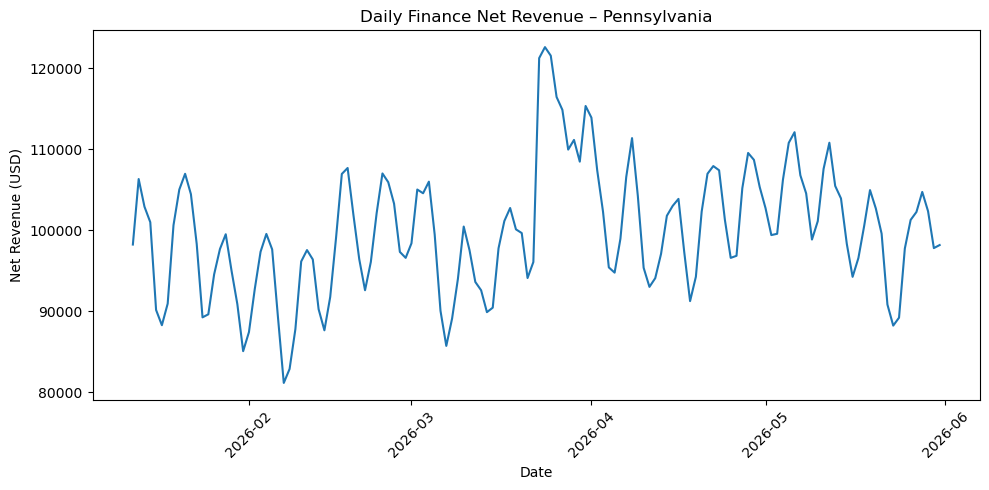

In [18]:
pa = daily_revenue[
    daily_revenue["state"] == "PA"
]

plt.figure(figsize=(10,5))

plt.plot(
    pa["date"],
    pa["net_revenue_usd"]
)

plt.xlabel("Date")
plt.ylabel("Net Revenue (USD)")
plt.title("Daily Finance Net Revenue – Pennsylvania")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

SECTION 2 — HYPOTHESIS DEFINITION

In [19]:
treatment_states = ["PA", "MI", "WI"]

print("Treatment states:",
      treatment_states)

Treatment states: ['PA', 'MI', 'WI']


In [20]:
treatment_revenue = markets[
    markets["state"].isin(treatment_states)
]["audited_last_28d_revenue_usd"].sum()

print("Treatment audited revenue:",
      treatment_revenue)

Treatment audited revenue: 6566264.930000001


In [21]:
treatment_share = (
    treatment_revenue / total_revenue
)

print(
    "Treatment revenue share:",
    treatment_share * 100,
    "%"
)

Treatment revenue share: 14.219555232051325 %


In [22]:
if 0.12 <= treatment_share <= 0.25:
    print("Revenue share constraint satisfied")
else:
    print("Revenue share constraint NOT satisfied")

Revenue share constraint satisfied


In [23]:
treatment_markets = markets[
    markets["state"].isin(treatment_states)
]

daily_bau_spend = (
    treatment_markets[
        "planned_bau_daily_spend_usd"
    ].sum()
)

print("Daily BAU spend:",
      daily_bau_spend)

Daily BAU spend: 21982.57


In [24]:
additional_daily_spend = (
    daily_bau_spend * 0.40
)

print(
    "Additional daily spend:",
    additional_daily_spend
)

Additional daily spend: 8793.028


In [25]:
additional_28day_spend = (
    additional_daily_spend * 28
)

print(
    "28-day additional spend:",
    additional_28day_spend
)

28-day additional spend: 246204.784


In [26]:
if additional_28day_spend <= 300000:
    print("Spend constraint satisfied")
else:
    print("Spend constraint NOT satisfied")

Spend constraint satisfied


SECTION 3 — EXPERIMENT DESIGN

In [27]:
display(
    markets[
        markets["state"].isin(treatment_states)
    ][
        [
            "state",
            "state_name",
            "can_increase_spend",
            "delivery_group",
            "planned_bau_daily_spend_usd",
            "audited_last_28d_revenue_usd"
        ]
    ]
)

,state,state_name,can_increase_spend,delivery_group,planned_bau_daily_spend_usd,audited_last_28d_revenue_usd
1,PA,Pennsylvania,1,PA,9461.11,2837053.11
2,MI,Michigan,1,MI,6506.54,1943186.37
3,WI,Wisconsin,1,WI,6014.92,1786025.45


In [28]:
eligible = markets[
    markets["state"].isin(treatment_states)
]["can_increase_spend"]

print(eligible)

if all(eligible == 1):
    print("All treatment states are eligible")
else:
    print("At least one treatment state is not eligible")

1    1
2    1
3    1
Name: can_increase_spend, dtype: int64
All treatment states are eligible


In [29]:
print(
    markets[
        markets["state"].isin(treatment_states)
    ][
        ["state", "delivery_group"]
    ]
)

  state delivery_group
1    PA             PA
2    MI             MI
3    WI             WI


In [30]:
comparison_candidates = markets[
    ~markets["state"].isin(treatment_states)
]

display(
    comparison_candidates[
        [
            "state",
            "state_name",
            "can_increase_spend",
            "delivery_group"
        ]
    ]
)

,state,state_name,can_increase_spend,delivery_group
0,OH,Ohio,1,OH
4,MO,Missouri,1,MO
5,IN,Indiana,1,IN
6,TN,Tennessee,1,TN
7,KY,Kentucky,1,KY
8,CA,California,0,CA
9,TX,Texas,1,TX
10,FL,Florida,1,FL
11,GA,Georgia,1,GA
12,NC,North Carolina,1,NC_SC


In [31]:
comparison_states = [
    "OH",
    "MO",
    "IN",
    "TN",
    "KY",
    "CO",
    "NC",
    "SC"
]

print("Comparison states:")
print(comparison_states)

Comparison states:
['OH', 'MO', 'IN', 'TN', 'KY', 'CO', 'NC', 'SC']


In [32]:
operations["start_date"] = pd.to_datetime(
    operations["start_date"]
)

operations["end_date"] = pd.to_datetime(
    operations["end_date"]
)

display(operations)

,state_scope,start_date,end_date,event,operations_note
0,ALL,2026-03-23,2026-03-29,National spring sale,Same offer and dates in all 16 states. No repe...
1,GA,2026-04-13,2026-04-16,Warehouse revenue feed incident,Daily sales export returned zero when incomple...
2,TX,2026-04-27,NaT,Fulfilment expansion,New distribution capacity went live. No rollba...
3,CO,2026-05-04,NaT,Platform reporting change,Paid-social attribution window changed from 7-...
4,FL,2026-06-08,2026-06-21,Local online promotion,"State-only 20% online discount and email push,..."
5,CA,2026-06-01,2026-06-28,Media contract,June paid-social spend must remain at business...
6,NC;SC,2026-06-01,2026-06-28,Shared media buying group,One budget and targeting instruction for NC an...


In [33]:
june_events = operations[
    (
        operations["start_date"]
        <= pd.Timestamp("2026-06-28")
    )
    &
    (
        operations["end_date"].fillna(
            pd.Timestamp("2026-12-31")
        )
        >= pd.Timestamp("2026-06-01")
    )
]

display(june_events)

,state_scope,start_date,end_date,event,operations_note
2,TX,2026-04-27,NaT,Fulfilment expansion,New distribution capacity went live. No rollba...
3,CO,2026-05-04,NaT,Platform reporting change,Paid-social attribution window changed from 7-...
4,FL,2026-06-08,2026-06-21,Local online promotion,"State-only 20% online discount and email push,..."
5,CA,2026-06-01,2026-06-28,Media contract,June paid-social spend must remain at business...
6,NC;SC,2026-06-01,2026-06-28,Shared media buying group,One budget and targeting instruction for NC an...


In [34]:
display(audience.head(20))

,state_a,state_b,cross_border_audience_share,basis
0,NC,SC,0.23,Share of observed paid-social users seen in bo...
1,OH,PA,0.03,Share of observed paid-social users seen in bo...
2,MI,IN,0.02,Share of observed paid-social users seen in bo...
3,TN,KY,0.04,Share of observed paid-social users seen in bo...


In [35]:
treatment_overlap = audience[
    audience["state_a"].isin(treatment_states)
    |
    audience["state_b"].isin(treatment_states)
]

display(treatment_overlap)

,state_a,state_b,cross_border_audience_share,basis
1,OH,PA,0.03,Share of observed paid-social users seen in bo...
2,MI,IN,0.02,Share of observed paid-social users seen in bo...


In [36]:
high_overlap = audience[
    audience["cross_border_audience_share"] >= 0.10
]

display(high_overlap)

,state_a,state_b,cross_border_audience_share,basis
0,NC,SC,0.23,Share of observed paid-social users seen in bo...


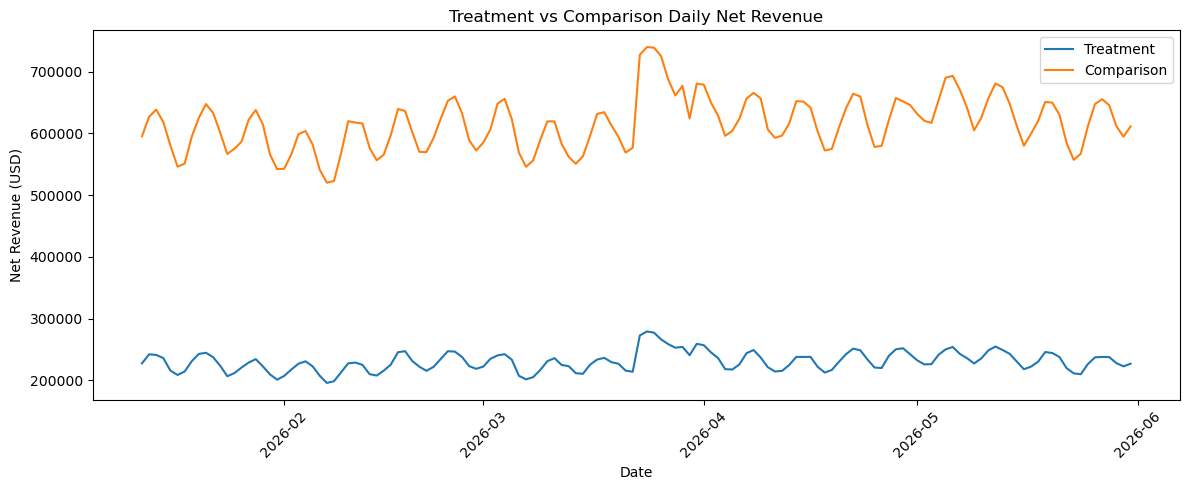

In [38]:
treatment_daily = daily[
    daily["state"].isin(treatment_states)
].groupby("date")[
    "net_revenue_usd"
].sum()

comparison_daily = daily[
    daily["state"].isin(comparison_states)
].groupby("date")[
    "net_revenue_usd"
].sum()
plt.figure(figsize=(12,5))

plt.plot(
    treatment_daily.index,
    treatment_daily.values,
    label="Treatment"
)

plt.plot(
    comparison_daily.index,
    comparison_daily.values,
    label="Comparison"
)

plt.xlabel("Date")
plt.ylabel("Net Revenue (USD)")
plt.title(
    "Treatment vs Comparison Daily Net Revenue"
)

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

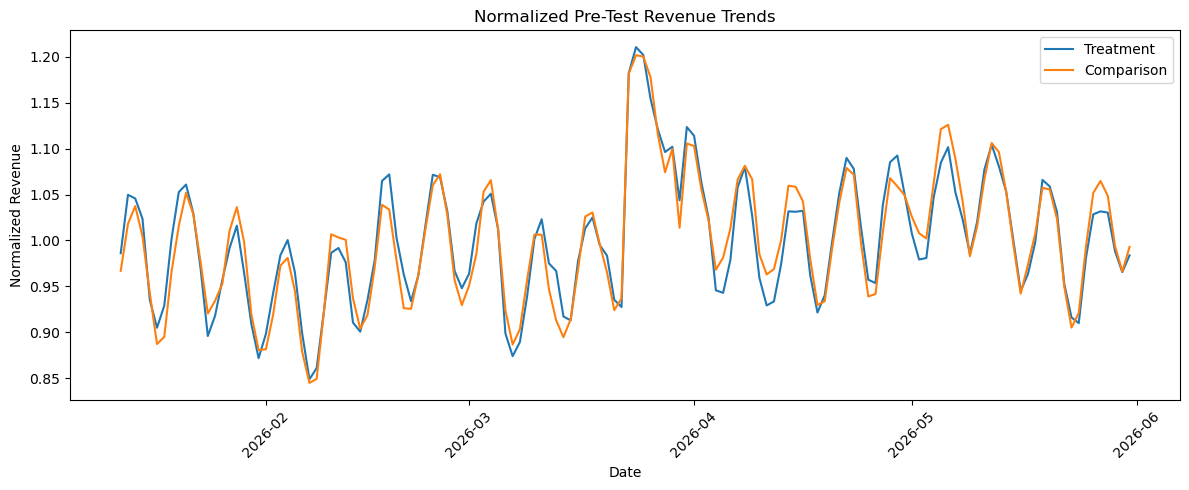

In [40]:
treatment_norm = (
    treatment_daily /
    treatment_daily.mean()
)

comparison_norm = (
    comparison_daily /
    comparison_daily.mean()
)
plt.figure(figsize=(12,5))

plt.plot(
    treatment_norm.index,
    treatment_norm.values,
    label="Treatment"
)

plt.plot(
    comparison_norm.index,
    comparison_norm.values,
    label="Comparison"
)

plt.xlabel("Date")
plt.ylabel("Normalized Revenue")
plt.title(
    "Normalized Pre-Test Revenue Trends"
)

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [41]:
from scipy.optimize import nnls

# Treatment aggregate
treatment = (
    daily[daily["state"].isin(treatment_states)]
    .groupby("date")["net_revenue_usd"]
    .sum()
)

# Candidate donor states
donors = [
    "OH", "MO", "IN", "TN",
    "KY", "CO", "NC", "SC"
]

# Create donor matrix
donor_data = []

for state in donors:
    temp = (
        daily[daily["state"] == state]
        .groupby("date")["net_revenue_usd"]
        .sum()
    )
    
    donor_data.append(temp)

X = pd.concat(
    donor_data,
    axis=1
)

X.columns = donors

# Align data
combined = pd.concat(
    [treatment, X],
    axis=1
).dropna()

y = combined.iloc[:, 0].values
X = combined.iloc[:, 1:].values

In [42]:
weights, residual = nnls(X, y)

weights = weights / weights.sum()

weight_table = pd.DataFrame({
    "State": donors,
    "Weight": weights
})

weight_table = weight_table.sort_values(
    "Weight",
    ascending=False
)

display(weight_table)

,State,Weight
4,KY,0.297029
1,MO,0.189556
6,NC,0.171106
0,OH,0.129567
2,IN,0.110844
5,CO,0.063091
3,TN,0.038807
7,SC,0.000000


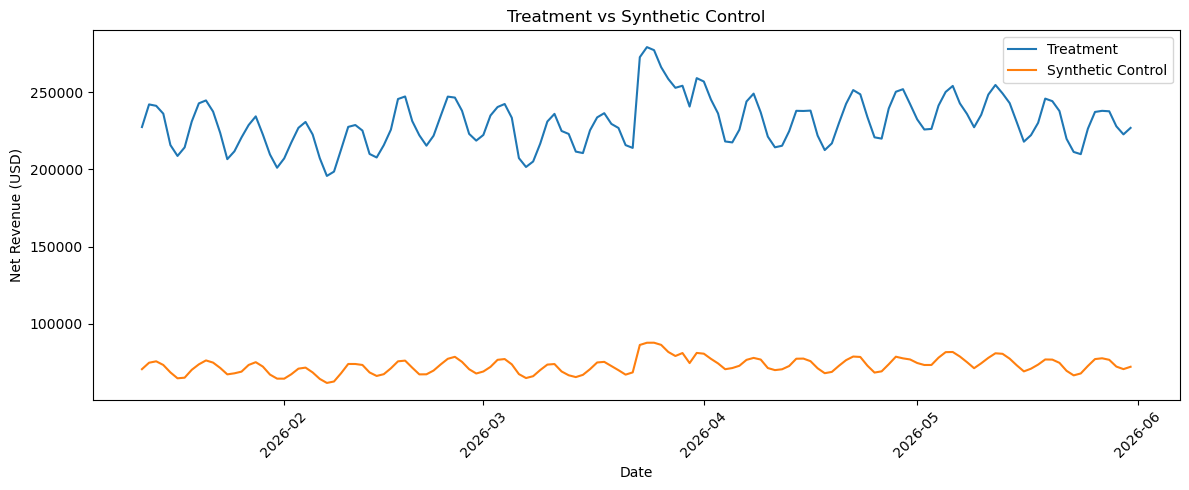

In [43]:
synthetic_control = X @ weights
plt.figure(figsize=(12,5))

plt.plot(
    combined.index,
    y,
    label="Treatment"
)

plt.plot(
    combined.index,
    synthetic_control,
    label="Synthetic Control"
)

plt.xlabel("Date")
plt.ylabel("Net Revenue (USD)")
plt.title(
    "Treatment vs Synthetic Control"
)

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [44]:
mape = np.mean(
    np.abs(
        (y - synthetic_control) / y
    )
)

print(
    "Pre-test MAPE:",
    round(mape * 100, 2),
    "%"
)

Pre-test MAPE: 68.32 %


In [45]:
correlation = np.corrcoef(
    y,
    synthetic_control
)[0,1]

print(
    "Pre-test correlation:",
    round(correlation, 3)
)

Pre-test correlation: 0.965


In [46]:
baseline_revenue = treatment.sum()

target_lift = baseline_revenue * 0.025

print(
    "Baseline treatment revenue:",
    baseline_revenue
)

print(
    "2.5% target lift:",
    target_lift
)

Baseline treatment revenue: 32278395.520000003
2.5% target lift: 806959.8880000002


In [47]:
expected_revenue = (
    baseline_revenue * 1.025
)

print(
    "Revenue with 2.5% lift:",
    expected_revenue
)

Revenue with 2.5% lift: 33085355.408


In [48]:
summary = pd.DataFrame({
    "Metric": [
        "Treatment states",
        "Comparison states",
        "Treatment revenue share",
        "Daily BAU spend",
        "Additional daily spend",
        "Additional 28-day spend",
        "Spend cap",
        "Planning effect",
        "Pre-test MAPE",
        "Pre-test correlation"
    ],
    
    "Value": [
        ", ".join(treatment_states),
        ", ".join(comparison_states),
        f"{treatment_share*100:.2f}%",
        f"${daily_bau_spend:,.2f}",
        f"${additional_daily_spend:,.2f}",
        f"${additional_28day_spend:,.2f}",
        "$300,000",
        "2.5%",
        f"{mape*100:.2f}%",
        f"{correlation:.3f}"
    ]
})

display(summary)

,Metric,Value
0,Treatment states,"PA, MI, WI"
1,Comparison states,"OH, MO, IN, TN, KY, CO, NC, SC"
2,Treatment revenue share,14.22%
3,Daily BAU spend,"$21,982.57"
4,Additional daily spend,"$8,793.03"
5,Additional 28-day spend,"$246,204.78"
6,Spend cap,"$300,000"
7,Planning effect,2.5%
8,Pre-test MAPE,68.32%
9,Pre-test correlation,0.965


In [50]:
summary.to_excel(
    "marketing_experiment_summary.xlsx",
    index=False
)

SECTION 4 — RISKS

In [52]:
audience.sort_values(
    "cross_border_audience_share",
    ascending=False
).head(10)

,state_a,state_b,cross_border_audience_share,basis
0,NC,SC,0.23,Share of observed paid-social users seen in bo...
3,TN,KY,0.04,Share of observed paid-social users seen in bo...
1,OH,PA,0.03,Share of observed paid-social users seen in bo...
2,MI,IN,0.02,Share of observed paid-social users seen in bo...


In [53]:
daily[
    daily["revenue_feed_complete"] == 0
][
    ["date", "state", "revenue_feed_complete"]
]

,date,state,revenue_feed_complete
1459,2026-04-13,GA,0
1475,2026-04-14,GA,0
1491,2026-04-15,GA,0
1507,2026-04-16,GA,0


In [54]:
daily[
    daily["net_revenue_usd"].isna()
][
    ["date", "state", "net_revenue_usd"]
]

,date,state,net_revenue_usd
339,2026-02-02,GA,NaN
387,2026-02-05,GA,NaN
451,2026-02-09,GA,NaN
499,2026-02-12,GA,NaN
563,2026-02-16,GA,NaN
611,2026-02-19,GA,NaN
675,2026-02-23,GA,NaN
723,2026-02-26,GA,NaN
